In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import shapiro

In [7]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


shapiro-Wilk p-value:  1.9863474999979633e-11
Not normal


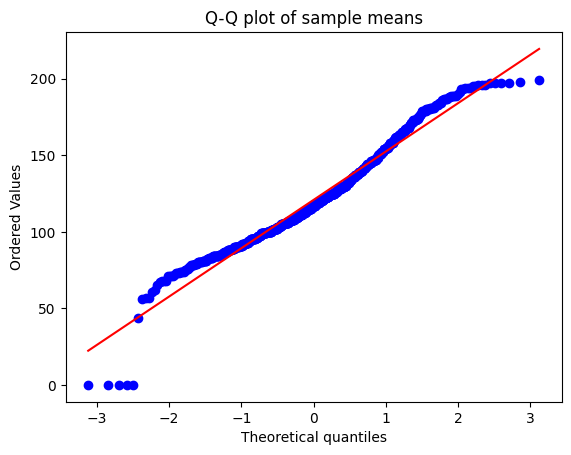

In [9]:
shapiro_test=stats.shapiro(df["Glucose"])
print("shapiro-Wilk p-value: ",shapiro_test.pvalue)
if shapiro_test.pvalue<0.05:
    print("Not normal")
else:
    print("Normal distribution")

stats.probplot(df["Glucose"], dist="norm", plot=plt)
plt.title("Q-Q plot of sample means")
plt.show()

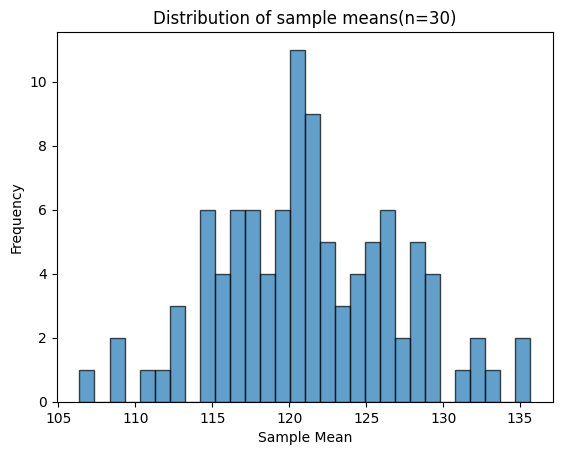

In [11]:
#Central Limit Theorem
sample_means=[]
n_samples=100
sample_size=30

for _ in range(n_samples):
    sample =df["Glucose"].sample(n=sample_size, replace=True)
    sample_means.append(sample.mean())

#PLot the distribution of sample means
plt.hist(sample_means, bins=30, edgecolor='k',alpha=0.7)
plt.title("Distribution of sample means(n=30)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

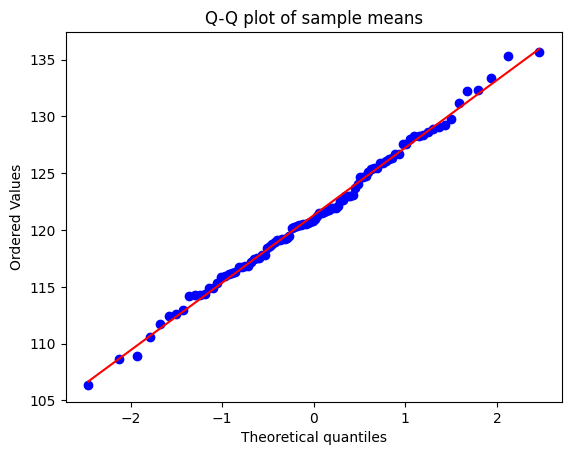

In [12]:
stats.probplot(sample_means,dist="norm",plot=plt)
plt.title("Q-Q plot of sample means")
plt.show()

In [13]:
shapiro_test =stats.shapiro(sample_means)
print("Shapiro-Wilk p-value:",shapiro_test.pvalue)

if shapiro_test.pvalue<0.05:
    print("Not normal")
else:
    print("Normal distribution")

Shapiro-Wilk p-value: 0.9612403789617429
Normal distribution
